In [1]:
!pip install music21

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.1/20.1 MB 32.0 MB/s  0:00:00 34.5 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [music21]━━━ 1/2 [music21]


In [3]:
import sys
print(sys.executable)

/Users/vikasshukla/.pyenv/versions/3.11.6/bin/python


In [4]:
import sys
!{sys.executable} -m pip install music21

  Using cached music21-10.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached jsonpickle-4.1.2-py3-none-any.whl.metadata (8.1 kB)
Using cached music21-10.3.0-py3-none-any.whl (20.1 MB)
Using cached jsonpickle-4.1.2-py3-none-any.whl (47 kB)

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: /Users/vikasshukla/.pyenv/versions/3.11.6/bin/python -m pip install --upgrade pip


In [5]:
import music21
print(music21.__version__)

10.3.0


In [6]:
from music21 import stream, note, tempo, instrument

In [8]:
import random

In [9]:
import random
from music21 import stream, note, tempo, instrument

melody_notes = ["C4", "D4", "E4", "G4", "A4", "C5"]

melody = stream.Stream()
melody.append(instrument.Piano())
melody.append(tempo.MetronomeMark(number=120))

for i in range(32):
    pitch = random.choice(melody_notes)
    duration = random.choice([0.25, 0.5, 1.0])

    n = note.Note(pitch)
    n.quarterLength = duration
    melody.append(n)

print("Generated melody with", len(melody.notes), "notes")

Generated melody with 32 notes


In [10]:
melody.show("text")

{0.0} <music21.instrument.Piano 'Piano'>
{0.0} <music21.tempo.MetronomeMark animato Quarter=120>
{0.0} <music21.note.Note A>
{0.5} <music21.note.Note E>
{1.5} <music21.note.Note G>
{2.5} <music21.note.Note E>
{3.0} <music21.note.Note C>
{4.0} <music21.note.Note A>
{4.5} <music21.note.Note E>
{5.5} <music21.note.Note C>
{6.5} <music21.note.Note C>
{7.5} <music21.note.Note C>
{8.5} <music21.note.Note C>
{9.5} <music21.note.Note C>
{10.5} <music21.note.Note D>
{10.75} <music21.note.Note C>
{11.25} <music21.note.Note D>
{11.5} <music21.note.Note C>
{12.0} <music21.note.Note A>
{12.25} <music21.note.Note C>
{12.75} <music21.note.Note E>
{13.75} <music21.note.Note D>
{14.75} <music21.note.Note G>
{15.25} <music21.note.Note G>
{16.25} <music21.note.Note A>
{16.75} <music21.note.Note A>
{17.75} <music21.note.Note C>
{18.75} <music21.note.Note D>
{19.25} <music21.note.Note C>
{19.75} <music21.note.Note C>
{20.0} <music21.note.Note G>
{20.5} <music21.note.Note D>
{20.75} <music21.note.Note C>
{2

In [11]:
midi_file = "generated_melody.mid"
melody.write("midi", fp=midi_file)

print("MIDI file created:", midi_file)

MIDI file created: generated_melody.mid


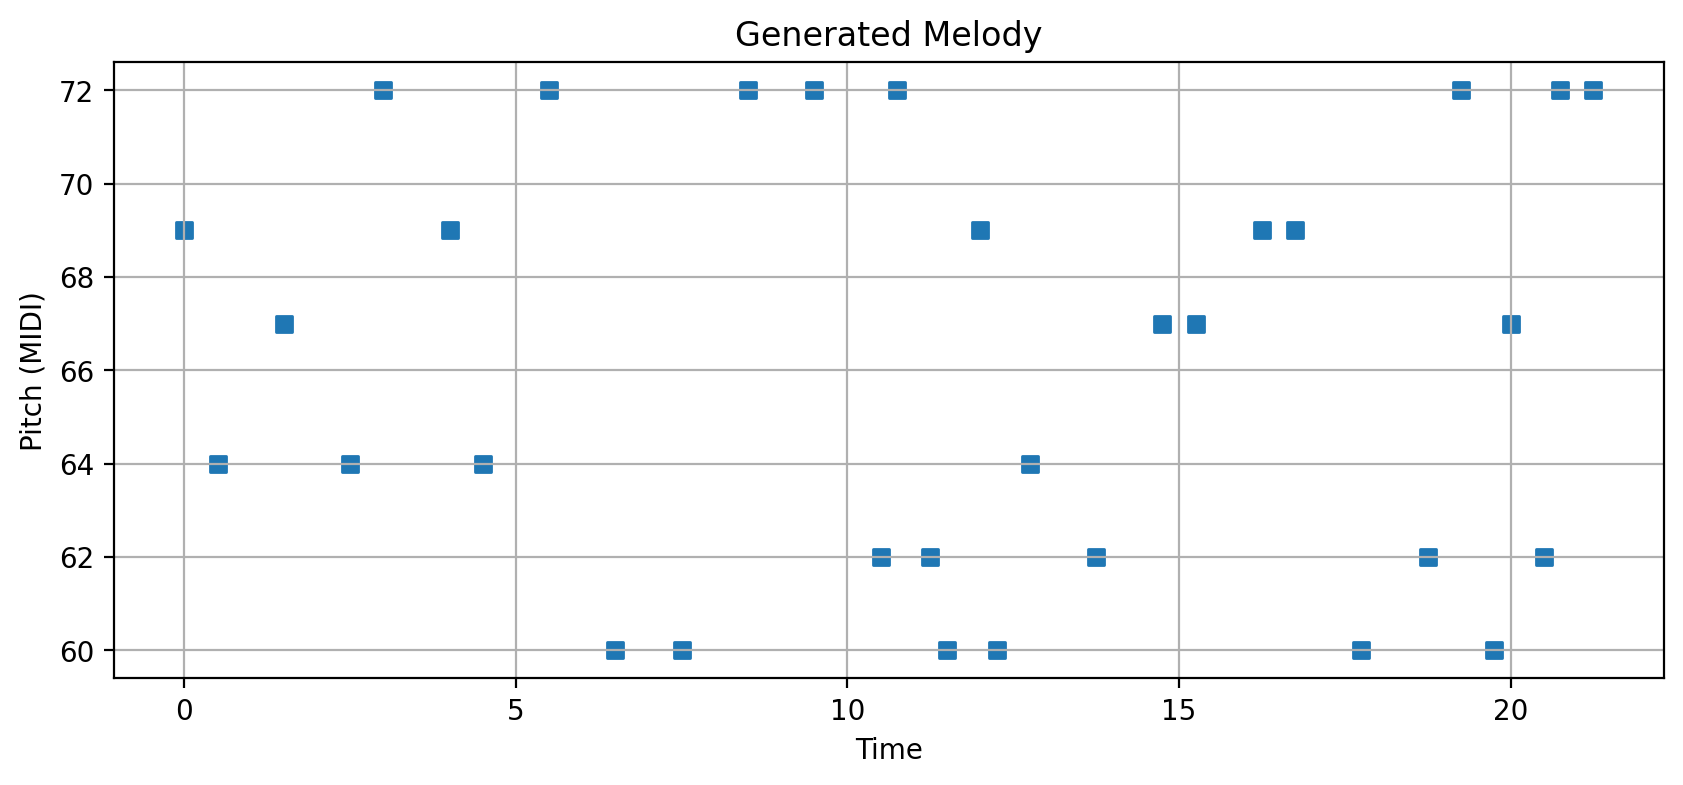

In [12]:
import matplotlib.pyplot as plt

pitch_map = {
    "C4": 60,
    "D4": 62,
    "E4": 64,
    "G4": 67,
    "A4": 69,
    "C5": 72
}

times = []
pitches = []

current_time = 0

for n in melody.notes:
    times.append(current_time)
    pitches.append(pitch_map[n.nameWithOctave])
    current_time += n.quarterLength

plt.figure(figsize=(10, 4))
plt.scatter(times, pitches, marker="s")
plt.title("Generated Melody")
plt.xlabel("Time")
plt.ylabel("Pitch (MIDI)")
plt.grid(True)
plt.show()